# Question 4: When applying PCA to all player-level statistics, what do the principal components at an 80% level represent, and how well do these components separate meaningful player archetypes (ex: shooters, creators, rim protectors, slashers)?


In [12]:
# 1. Imports
import pandas as pd
import numpy as np
import os
import re


from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler


import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid", context="talk")

In [13]:
# 2. Load Player Stats

STATS_DIR = "NBAPlayerStatsJoined"

all_players = []

for fname in sorted(os.listdir(STATS_DIR)):
    if fname.endswith(".csv"):
        season = fname.replace("NBAPlayerStatsJoined", "").replace(".csv","")
        df = pd.read_csv(os.path.join(STATS_DIR, fname))
        df["Season"] = season
        all_players.append(df)

players = pd.concat(all_players, ignore_index=True)
print(players.shape)



def season_from_filename(fname: str) -> str:
    """
    Extract a season tag like '2020-21' from filenames such as
    'NBAPlayerStatsJoined(2020-21).csv' or 'PlayerArchetypes(2020-21).csv'.
    """
    base = os.path.basename(fname)
    m = re.search(r"\((\d{4}-\d{2})\)", base)
    if m:
        return m.group(1)
    else:
        return os.path.splitext(base)[0]


(3665, 50)


In [14]:
# 3. Cleaning 

players = players[(players["G"] >= 15) & (players["MP"] >= 10)]
print(players.shape)

players = players[players["Team"] != "2TM"].copy()

non_numeric = ["Player", "Team", "Pos", "Season"]
numeric_players = players.drop(columns=non_numeric)

# Drop columns with >10% missing
col_missing = numeric_players.isna().mean()
cols_to_keep = col_missing[col_missing < 0.10].index
numeric_players = numeric_players[cols_to_keep].copy()
print("Remaining columns:", len(numeric_players.columns))

# drop any remaining rows that still have NaNs
row_mask = numeric_players.notna().all(axis=1)
numeric_players = numeric_players.loc[row_mask].reset_index(drop=True)

# keep players aligned with numeric_players
players = players.loc[row_mask].reset_index(drop=True)

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(numeric_players)
X = pd.DataFrame(X_scaled, columns=numeric_players.columns)

(2563, 50)
Remaining columns: 46


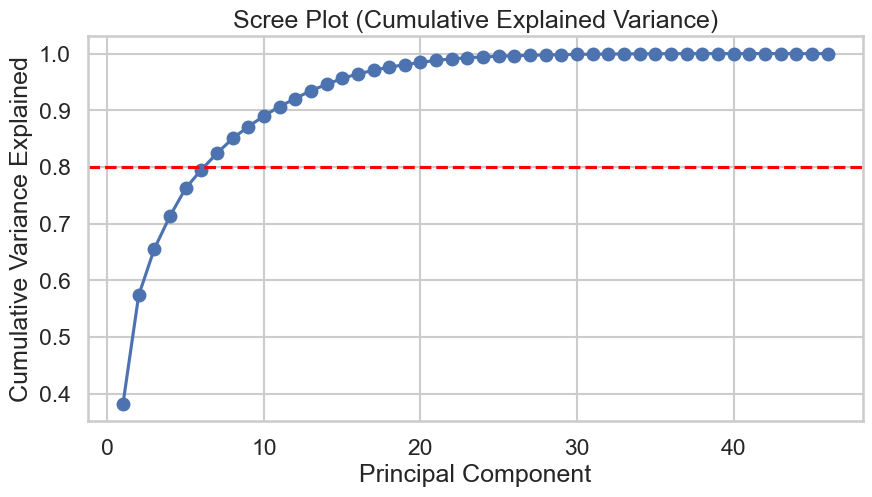

In [15]:
# 4. PCA

pca = PCA(n_components=None)
pca.fit(X)

explained = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(10,5))
plt.plot(range(1, len(explained)+1), explained, marker="o")
plt.axhline(0.8, color="red", linestyle="--")
plt.title("Scree Plot (Cumulative Explained Variance)")
plt.xlabel("Principal Component")
plt.ylabel("Cumulative Variance Explained")
plt.show()

In [16]:
# 5. Score Table

scores = pca.transform(X)[:, :2]     # PC1 + PC2 only
players_pca = pd.DataFrame(scores, columns=["PC1","PC2"])
players_pca["Player"] = players["Player"].values
players_pca["Team"] = players["Team"].values
players_pca["Pos"] = players["Pos"].values
players_pca["Season"] = players["Season"].values
players_pca["Archetype"] = "Unknown"

In [17]:
# 6. Attach Archetypes

ARCH_DIR = "NBAPlayerArchetypesAssigned"
all_arch = []

for fname in sorted(os.listdir(ARCH_DIR)):
    if not fname.endswith(".csv"):
        continue

    season = season_from_filename(fname)
    path = os.path.join(ARCH_DIR, fname)

    df_arch = pd.read_csv(path)

    # strip any  whitespace in column 
    df_arch.columns = [c.strip() for c in df_arch.columns]

    if "Player" not in df_arch.columns or "Archetype" not in df_arch.columns:
        raise ValueError(f"'Player' or 'Archetype' missing in {fname}: {df_arch.columns}")

    df_arch = df_arch[["Player", "Archetype"]].copy()
    df_arch["Season"] = season

    df_arch["Player"] = df_arch["Player"].astype(str).str.strip()

    all_arch.append(df_arch)

# single archetype table
arch = pd.concat(all_arch, ignore_index=True)

players_pca["Player"] = players_pca["Player"].astype(str).str.strip()

if "Season" in players_pca.columns:
    players_pca = players_pca.merge(
        arch[["Player", "Season", "Archetype"]],
        on=["Player", "Season"],
        how="left"
    )
else:
    players_pca = players_pca.merge(
        arch[["Player", "Archetype"]],
        on="Player",
        how="left"
    )

In [18]:
# 7. Build master archetype table across seasons 
ARCH_DIR = "NBAPlayerArchetypesAssigned"  # adjust if your path is different

all_arch = []
for fname in sorted(os.listdir(ARCH_DIR)):
    if not fname.endswith(".csv"):
        continue

    path = os.path.join(ARCH_DIR, fname)
    a = pd.read_csv(path)

    # Clean up column names and text
    a.columns = a.columns.str.strip()
    if "Player" not in a.columns:
        raise ValueError(f"'Player' column not found in {fname}")
    if "Archetype" not in a.columns:
        possible = [c for c in a.columns if "Archetype" in c]
        if len(possible) == 1:
            a = a.rename(columns={possible[0]: "Archetype"})
        else:
            raise ValueError(f"'Archetype' column not found in {fname}, columns = {a.columns}")

    a["Player"] = a["Player"].astype(str).str.strip()
    a["Archetype"] = a["Archetype"].astype(str).str.strip()

    all_arch.append(a[["Player", "Archetype"]])

arch = pd.concat(all_arch, ignore_index=True)

arch = arch.drop_duplicates(subset=["Player"])

# Merge archetypes into players_pca 
players_pca["Player"] = players_pca["Player"].astype(str).str.strip()

players_pca = players_pca.merge(
    arch,
    on="Player",
    how="left"
)

# Fill missing labels so hue has no NaNs
players_pca["Archetype"] = players_pca["Archetype"].fillna("Unclassified")

In [ ]:
# 8. PCA Scatter Plot (interactive hover)

try:
    import plotly.express as px

    hover_cols = ["Player", "Pos", "Team", "Season", "Archetype"]
    # Keep tooltips readable and avoid duplicating axis coords
    fig = px.scatter(
        players_pca,
        x="PC1",
        y="PC2",
        color="Archetype",
        hover_data={
            "Player": True,
            "Pos": True,
            "Team": True,
            "Season": True,
            "Archetype": True,
            "PC1": False,
            "PC2": False,
        },
        title="PCA Scatter Plot Colored by Archetype",
    )

    fig.update_traces(marker=dict(size=7, opacity=0.75))
    fig.add_hline(y=0, line_width=1, line_dash="dash", line_color="black")
    fig.add_vline(x=0, line_width=1, line_dash="dash", line_color="black")
    fig.update_layout(
        legend_title_text="Archetype",
        xaxis_title="PC1",
        yaxis_title="PC2",
    )

    fig.show()

except ImportError:
    # Fallback to your original static seaborn plot
    plt.figure(figsize=(12,10))
    sns.scatterplot(
        data=players_pca,
        x="PC1", y="PC2",
        hue="Archetype",
        palette="tab20",
        alpha=0.7
    )
    plt.title("PCA Scatter Plot Colored by Archetype")
    plt.axhline(0,color='black')
    plt.axvline(0,color='black')
    plt.legend(bbox_to_anchor=(1,1))
    plt.show()

In [ ]:
# 8b. PCA Pairwise Grid (PC1–PC7) — interactive triangular grid
# Notes:
# - This creates 21 scatterplots (upper triangle) and can be heavy.
# - If rendering is slow, use the SAMPLE_N option below.

import numpy as np
import pandas as pd

from plotly.subplots import make_subplots
import plotly.graph_objects as go

PC_MAX = 7
SAMPLE_N = None  # set to e.g. 2000 to sample for faster rendering

if "pca" not in globals() or "X" not in globals() or "players" not in globals():
    raise NameError("Expected `pca`, `X`, and `players` from earlier cells.")

# Compute PC1–PC7 scores
scores7 = pca.transform(X)[:, :PC_MAX]
pc_cols = [f"PC{i}" for i in range(1, PC_MAX + 1)]

players_pca7 = pd.DataFrame(scores7, columns=pc_cols)
players_pca7["Player"] = players["Player"].values
players_pca7["Pos"] = players["Pos"].values
players_pca7["Team"] = players["Team"].values
players_pca7["Season"] = players["Season"].values

# Reuse archetype labels from your earlier merge if available
if "players_pca" in globals() and "Archetype" in players_pca.columns:
    players_pca7["Archetype"] = players_pca["Archetype"].values
else:
    players_pca7["Archetype"] = "Unclassified"

# Optional sampling for performance
if SAMPLE_N is not None and len(players_pca7) > SAMPLE_N:
    players_pca7 = players_pca7.sample(SAMPLE_N, random_state=42).reset_index(drop=True)

# Consistent colors by archetype
unique_arch = sorted(players_pca7["Archetype"].astype(str).unique())
palette = [
    "#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd",
    "#8c564b", "#e377c2", "#7f7f7f", "#bcbd22", "#17becf",
]
color_map = {a: palette[i % len(palette)] for i, a in enumerate(unique_arch)}
players_pca7["_color"] = players_pca7["Archetype"].astype(str).map(color_map)

customdata = np.stack(
    [
        players_pca7["Player"].astype(str).values,
        players_pca7["Pos"].astype(str).values,
        players_pca7["Team"].astype(str).values,
        players_pca7["Season"].astype(str).values,
        players_pca7["Archetype"].astype(str).values,
    ],
    axis=1,
)

hover_tmpl = (
    "Player: %{customdata[0]}<br>"
    "Pos: %{customdata[1]}<br>"
    "Team: %{customdata[2]}<br>"
    "Season: %{customdata[3]}<br>"
    "Archetype: %{customdata[4]}<br>"
    "PCx: %{x:.2f}<br>"
    "PCy: %{y:.2f}<extra></extra>"
)

# Upper-triangular pairwise grid (j > i)
fig = make_subplots(
    rows=PC_MAX,
    cols=PC_MAX,
    shared_xaxes=False,
    shared_yaxes=False,
    horizontal_spacing=0.01,
    vertical_spacing=0.01,
)

for i in range(1, PC_MAX + 1):
    for j in range(1, PC_MAX + 1):
        if j <= i:
            continue

        xcol = f"PC{j}"
        ycol = f"PC{i}"

        fig.add_trace(
            go.Scattergl(
                x=players_pca7[xcol],
                y=players_pca7[ycol],
                mode="markers",
                marker=dict(size=4, opacity=0.65, color=players_pca7["_color"]),
                customdata=customdata,
                hovertemplate=hover_tmpl,
                showlegend=False,
            ),
            row=i,
            col=j,
        )

        # reduce clutter: label only the top row x-axes and rightmost column y-axes
        if i == 1:
            fig.update_xaxes(title_text=f"PC{j}", row=i, col=j)
        if j == PC_MAX:
            fig.update_yaxes(title_text=f"PC{i}", row=i, col=j)

# Add a compact legend (one dummy point per archetype)
for arch in unique_arch:
    fig.add_trace(
        go.Scattergl(
            x=[None],
            y=[None],
            mode="markers",
            marker=dict(size=8, color=color_map[arch]),
            name=str(arch),
            showlegend=True,
        ),
        row=1,
        col=1,
    )

fig.update_layout(
    title=f"Interactive PCA Pairwise Grid (PC1–PC{PC_MAX}) — upper triangle",
    height=220 * PC_MAX,
    width=220 * PC_MAX,
    legend_title_text="Archetype",
)

OUT_HTML = f"pca_pairwise_grid_PC1_PC{PC_MAX}.html"
fig.write_html(OUT_HTML, include_plotlyjs="cdn")
print(f"Saved interactive plot to: {OUT_HTML}")

fig.show()

In [20]:
# 9. Table of PCs and stats

# After PCA is fit
features = list(numeric_players.columns)

# PCs to examine
pcs_to_show = 7   # change to any number you want

# Build a dataframe of loadings
loadings = pd.DataFrame(
    pca.components_[:pcs_to_show], 
    columns=features,
    index=[f"PC{i+1}" for i in range(pcs_to_show)]
)

# Display neatly
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

display(loadings.T)   # transpose so features are rows and PCs are columns

,PC1,PC2,PC3,PC4,PC5,PC6,PC7
Age,0.019135,-0.021037,0.105607,0.113299,-0.094191,-0.254182,0.068432
G,0.089483,-0.006088,0.157353,0.009280,0.291504,0.427557,-0.205319
GS,0.170040,-0.063942,0.019258,-0.022761,0.282359,0.243467,0.005128
MP,0.186594,-0.133843,-0.019285,-0.035410,0.191406,0.074396,0.171093
FG,0.213698,-0.115764,-0.043120,-0.110888,0.001966,-0.003657,0.034917
FGA,0.192485,-0.173726,-0.067909,-0.108476,0.036642,-0.036544,0.029161
FG%,0.115697,0.236441,0.109929,-0.053223,-0.161887,0.197472,0.201251
3P,0.086181,-0.250558,0.160050,-0.094314,0.123680,-0.160150,0.150170
3PA,0.084262,-0.261905,0.106690,-0.096585,0.144562,-0.159384,0.126945
3P%,0.003827,-0.147664,0.225872,-0.015849,-0.012792,-0.145250,0.168131


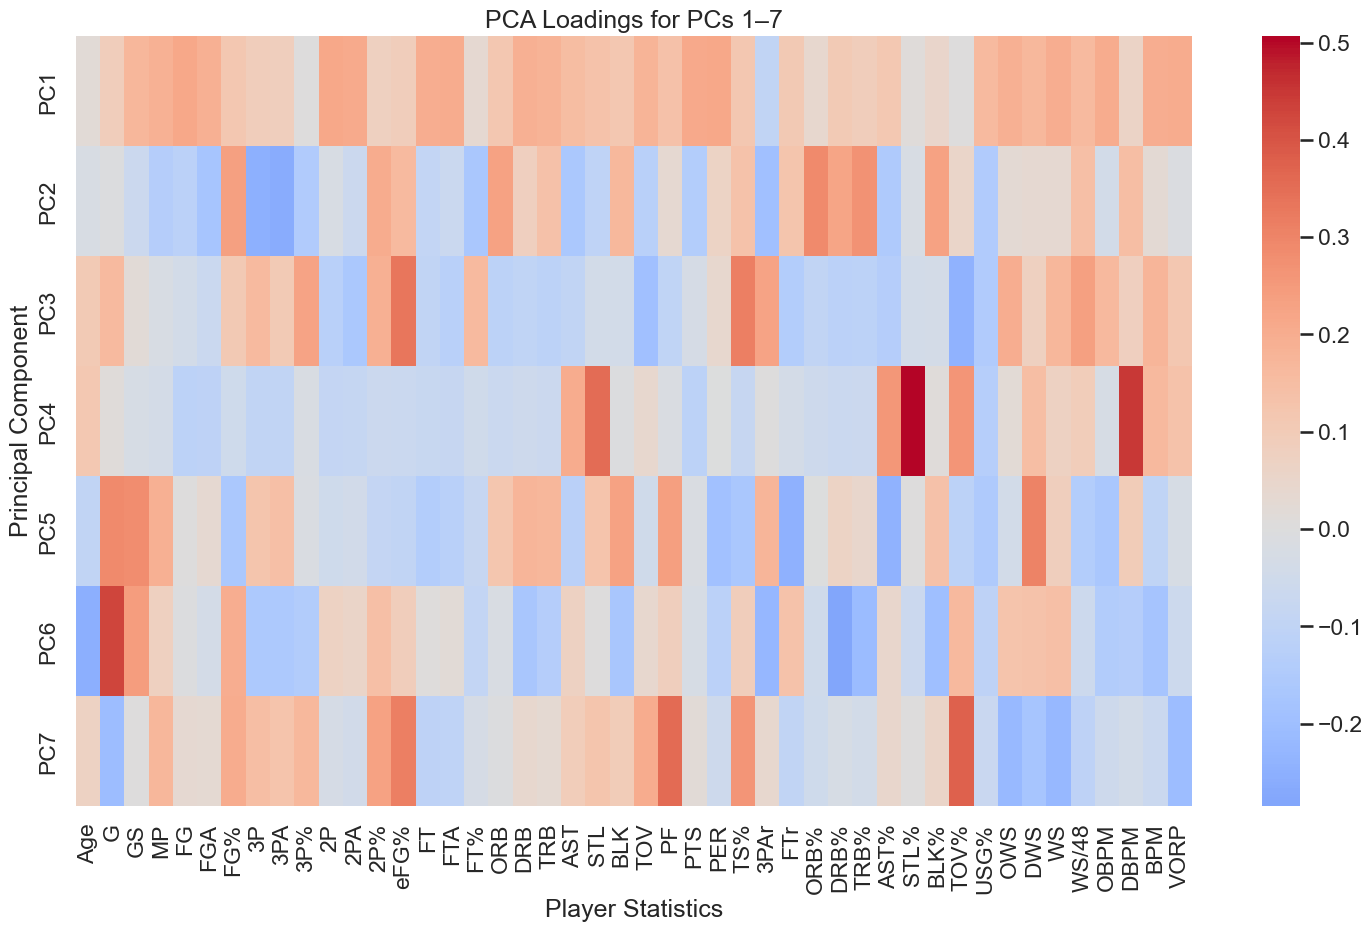

In [21]:
# 10. Heatmap

plt.figure(figsize=(18,10))
sns.heatmap(
    loadings,
    cmap="coolwarm",
    center=0,
    annot=False
)

plt.title("PCA Loadings for PCs 1–7")
plt.xlabel("Player Statistics")
plt.ylabel("Principal Component")
plt.show()